In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1]:

def comb(folder, i):

    # Load both CSVs
    df_kl = pd.read_csv(f"results/{folder}/{i}/kl_results.csv")
    df_ret = pd.read_csv(f"results/{folder}/{i}/agent_perf.csv")
    #df_ret = pd.read_csv(f"results/test/{i}/train_loss.csv")

    # Make sure index column is treated as string or integer consistently
    df_kl["index"] = df_kl["index"].astype(str)
    df_ret["index"] = df_ret["index"].astype(str)

    # Merge and keep only shared indices
    df_common = df_kl.merge(df_ret, on="index", how="inner")

    return df_common

<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/var/folders/v5/q_0l9ch13dg43c6js8gmw9dw0000gn/T/ipykernel_12202/585119568.py:7: SyntaxWarning: invalid escape sequence '\p'
  plt.scatter(df_common['linear'], df_common['success_rate'], c='darkviolet', alpha=0.7, label = 'Single $V^\pi$')
/var/folders/v5/q_0l9ch13dg43c6js8gmw9dw0000gn/T/ipykernel_12202/585119568.py:15: SyntaxWarning: invalid escape sequence '\p'
  plt.scatter(df_common['linear'],  df_common['success_rate'], c='seagreen', alpha=0.7, label = 'Single $V^\pi$ + Obs. Pred.')
/var/folders/v5/q_0l9ch13dg43c6js8gmw9dw0000gn/T/ipykernel_12202/585119568.py:23: SyntaxWarning: inva

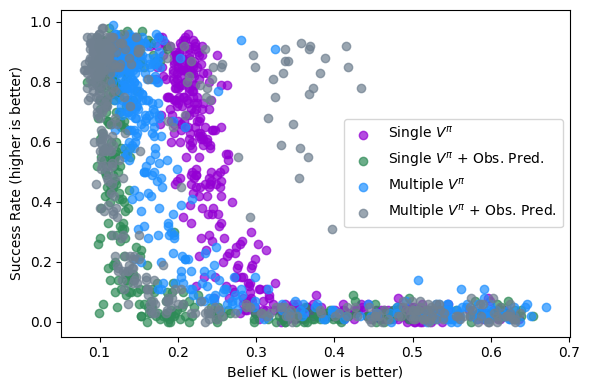

In [3]:

plt.figure(figsize=(6,4))

for i in range(25):
    df_common = comb(folder='test1',i=i)
    #print(df_common)
    if i == 0:
        plt.scatter(df_common['linear'], df_common['success_rate'], c='darkviolet', alpha=0.7, label = 'Single $V^\pi$')
    else:
        plt.scatter(df_common['linear'], df_common['success_rate'], c='darkviolet', alpha=0.7)

for i in range(25):
    df_common = comb(folder='test3',i=i)
    #print(df_common)
    if i == 0:
        plt.scatter(df_common['linear'],  df_common['success_rate'], c='seagreen', alpha=0.7, label = 'Single $V^\pi$ + Obs. Pred.')
    else:
        plt.scatter(df_common['linear'],  df_common['success_rate'], c='seagreen', alpha=0.7)

for i in range(25):
    df_common = comb(folder='test2',i=i)
    #print(df_common)
    if i == 0:
        plt.scatter(df_common['linear'], df_common['success_rate'], c='dodgerblue', alpha=0.7, label = 'Multiple $V^\pi$')
    else:
        plt.scatter(df_common['linear'], df_common['success_rate'], c='dodgerblue', alpha=0.7)

for i in range(25):
    df_common = comb(folder='test4',i=i)
    #print(df_common)
    if i ==0:
        plt.scatter(df_common['linear'], df_common['success_rate'], c='slategray', alpha=0.7, label = 'Multiple $V^\pi$ + Obs. Pred.')
    else:
        plt.scatter(df_common['linear'], df_common['success_rate'], c='slategray', alpha=0.7)

plt.xlabel("Belief KL (lower is better)")
plt.ylabel("Success Rate (higher is better)")
plt.legend()
plt.tight_layout()
#plt.xlim(0.08,0.7)
#plt.ylim(0.0,1.00)
#plt.xscale('exp')
#plt.savefig("figures/KL_succ.pdf")

(0.0, 1.0)

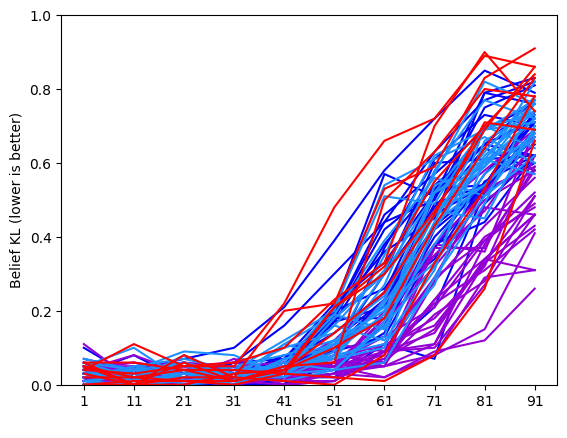

In [5]:
x = 'index'
y = 'success_rate'
for i in range(25):
    df_common = comb(folder='test',i=i)
    #print(df_common)
    plt.plot(df_common[x], df_common[y], c='blue')

for i in range(25):
    df_common = comb(folder='test2',i=i)
    #print(df_common)
    plt.plot(df_common[x], df_common[y], c='darkviolet')

for i in range(25):
    df_common = comb(folder='test3',i=i)
    #print(df_common)
    plt.plot(df_common[x], df_common[y], c='dodgerblue')

for i in range(10):
    df_common = comb(folder='test4',i=i)
    #print(df_common)
    plt.plot(df_common[x], df_common[y], c='red')

plt.xlabel("Chunks seen")
plt.ylabel("Belief KL (lower is better)")
#plt.xlim(0.08,0.7)
plt.ylim(0.0,1.00)
#plt.xscale('exp')

In [4]:
def extractor(folder, max_i):
    dfs = [comb(folder=folder,i=i) for i in range(max_i) ]
    for i, df in enumerate(dfs):
        df = df.copy()

        # Clean the index column
        df["index"] = pd.to_numeric(df["index"], errors="coerce")

        # # Optional: check if any conversion failed
        # if df["index"].isna().any():
        #     print(f"Warning: NaN created in df {i} during index conversion")

        # Set it as the actual index
        #df = df.set_index("index")

        dfs[i] = df
    # for df in dfs:
    #     df = df.copy()

    #     # Convert all columns except 'index' to numeric
    #     for col in df.columns:
    #         if col != "index":   # adjust if your index column name differs
    #             df[col] = pd.to_numeric(df[col], errors="coerce")

    #     cleaned_dfs.append(df)
    
    # Stack replicates along a new "replicate" axis
    panel = pd.concat(dfs, axis=0, keys=range(len(dfs)))

    #print(panel)
    #print(panel.dtypes)

    # Compute per-row means and stds across replicates
    mean_df = panel.groupby(level=1).mean()
    std_df  = panel.groupby(level=1).std()
    sem_df  = std_df/np.sqrt(max_i)

    return mean_df, std_df, sem_df



<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
/var/folders/v5/q_0l9ch13dg43c6js8gmw9dw0000gn/T/ipykernel_12202/1038764816.py:13: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(mean_df[x], mean_df[y], c=col, linewidth=3, label = 'Single $V^\pi$', alpha=0.7, marker='o')
/var/folders/v5/q_0l9ch13dg43c6js8gmw9dw0000gn/T/ipykernel_12202/1038764816.py:23: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(mean_df[x], mean_df[y], c=col, linewidth=3, label = 'Single $V^\pi$ + Obs. Pred.', alpha=0.7, marker='o')
/var/folders/v5/q_0l9ch13dg43c6js8gmw9dw0000gn/T/ipykernel_12202/1038764816.py:32: SyntaxWarning: invalid escape sequ

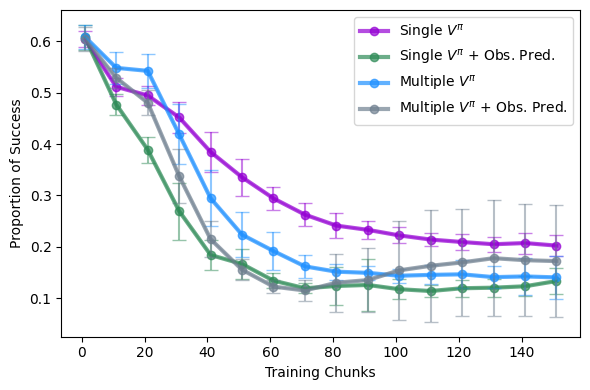

In [9]:
x = 'index'
#x = 'linear'
#y = 'success_rate'
y = 'linear'

plt.figure(figsize=(6,4))

mean_df, std_df, sem_df = extractor('test1',25)
#print(mean_df) 
#print(std_df)
col = 'darkviolet'

plt.plot(mean_df[x], mean_df[y], c=col, linewidth=3, label = 'Single $V^\pi$', alpha=0.7, marker='o')
#plt.fill_between(mean_df[x], mean_df[y] - std_df[y], mean_df[y] + std_df[y], color=col, alpha=0.1)
plt.errorbar(mean_df[x], mean_df[y],  std_df[y], color=col, alpha=0.5, capsize = 5)


mean_df, std_df, sem_df = extractor('test3',25)
#print(mean_df)
#print(std_df)
col = 'seagreen'

plt.plot(mean_df[x], mean_df[y], c=col, linewidth=3, label = 'Single $V^\pi$ + Obs. Pred.', alpha=0.7, marker='o')
#plt.fill_between(mean_df[x], mean_df[y] - std_df[y], mean_df[y] + std_df[y], color=col, alpha=0.1)
plt.errorbar(mean_df[x], mean_df[y],  std_df[y], color=col, alpha=0.5, capsize = 5)
col = 'dodgerblue'

mean_df, std_df, sem_df = extractor('test2',25)
#print(mean_df)
#print(std_df)

plt.plot(mean_df[x], mean_df[y], c=col, linewidth=3, label = 'Multiple $V^\pi$', alpha=0.7, marker='o')
#plt.fill_between(mean_df[x], mean_df[y] - std_df[y], mean_df[y] + std_df[y], color=col, alpha=0.1)
plt.errorbar(mean_df[x], mean_df[y],  std_df[y], color=col, alpha=0.5, capsize = 5)

mean_df, std_df, sem_df = extractor('test4',20)
#print(mean_df)
#print(std_df)
col = 'slategray'

plt.plot(mean_df[x], mean_df[y], c=col, linewidth=3, label = 'Multiple $V^\pi$ + Obs. Pred.', alpha=0.7, marker='o')
#plt.fill_between(mean_df[x], mean_df[y] - std_df[y], mean_df[y] + std_df[y], color=col, alpha=0.1)
plt.errorbar(mean_df[x], mean_df[y],  std_df[y], color=col, alpha=0.5, capsize = 5)

plt.xlabel("Training Chunks")
plt.ylabel("Proportion of Success")
plt.legend()
plt.tight_layout()
#plt.gca.invert_xaxis()
#plt.savefig("figures/train_succ.pdf")

In [19]:
#y = 'success_rate'
y = 'linear'

mean_df, std_df, sem_df = extractor('test2',25)
mean_1 = mean_df[y].iloc[-1] 
std_1 = std_df[y].iloc[-1]
print(mean_1, std_1)

mean_df, std_df, sem_df = extractor('test',25)

mean_2 = mean_df[y].iloc[-1]
std_2 = std_df[y].iloc[-1]
print(mean_2, std_2)

mean_df, std_df, sem_df = extractor('test3',25)

mean_3 = mean_df[y].iloc[-1]
std_3 = std_df[y].iloc[-1]
print(mean_3, std_3)

mean_df, std_df, sem_df = extractor('test4',20)

mean_4 = mean_df[y].iloc[-1]
std_4 = std_df[y].iloc[-1]
print(mean_4, std_4)

# perform significance tests of the differences between all pairwise setups at the final chunk
# aussume normal distribution and use t-test
# collect pairwise results in a table, and print them
from scipy import stats
setups = [
    ("Single Vπ", mean_1, std_1),
    ("Single Vπ + Obs Pred", mean_2, std_2),
    ("Multiple Vπ", mean_3, std_3),
    ("Multiple Vπ + Obs Pred", mean_4, std_4),
]
for i in range(len(setups)):
    for j in range(i+1, len(setups)):
        name_i, mean_i, std_i = setups[i]
        name_j, mean_j, std_j = setups[j]
        # t-test
        t_stat, p_value = stats.ttest_ind_from_stats(
            mean1=mean_i, std1=std_i, nobs1=25,
            mean2=mean_j, std2=std_j, nobs2=25,
            equal_var=False
        )
        print(f"t-test between {name_i} and {name_j}: t-statistic = {t_stat:.4f}, p-value = {p_value:.6f}")

0.2331272497177124 0.01647771138066149
0.11685134310722348 0.009915073867515702
0.1471189953804016 0.01625126610402918
0.12272850984334942 0.051243932455662014
t-test between Single Vπ and Single Vπ + Obs Pred: t-statistic = 30.2317, p-value = 0.000000
t-test between Single Vπ and Multiple Vπ: t-statistic = 18.5816, p-value = 0.000000
t-test between Single Vπ and Multiple Vπ + Obs Pred: t-statistic = 10.2548, p-value = 0.000000
t-test between Single Vπ + Obs Pred and Multiple Vπ: t-statistic = -7.9496, p-value = 0.000000
t-test between Single Vπ + Obs Pred and Multiple Vπ + Obs Pred: t-statistic = -0.5630, p-value = 0.578291
t-test between Multiple Vπ and Multiple Vπ + Obs Pred: t-statistic = 2.2685, p-value = 0.030981
